### Célula 1 — Carregando as tabelas da Gold

In [0]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Configurações visuais — estilo BI profissional
plt.rcParams["figure.figsize"]  = (10, 4)
plt.rcParams["axes.titlesize"]  = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"]  = False
plt.rcParams["axes.spines.right"] = False
sns.set_theme(style="whitegrid", palette="muted")

# Caminhos
GOLD_PATH   = "/Volumes/workspace/default/raw/gold/"
OUTPUT_DIR  = "/Volumes/workspace/default/raw/bi_charts/"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)                               # cria pasta de saída

# Carregando tabelas
f_tickets    = spark.read.format("delta").load(f"{GOLD_PATH}f_customer_support_tickets/")
dim_customer = spark.read.format("delta").load(f"{GOLD_PATH}dim_customer/")
dim_product  = spark.read.format("delta").load(f"{GOLD_PATH}dim_product/")
dim_type     = spark.read.format("delta").load(f"{GOLD_PATH}dim_type/")
dim_status   = spark.read.format("delta").load(f"{GOLD_PATH}dim_status/")
dim_priority = spark.read.format("delta").load(f"{GOLD_PATH}dim_priority/")
dim_channel  = spark.read.format("delta").load(f"{GOLD_PATH}dim_channel/")
dim_subject  = spark.read.format("delta").load(f"{GOLD_PATH}dim_subject/")

print("✅ Tabelas carregadas!")
print(f"Total de tickets: {f_tickets.count():,}")

✅ Tabelas carregadas!
Total de tickets: 8,469


### Célula 2 — KPI Cards + Gauge

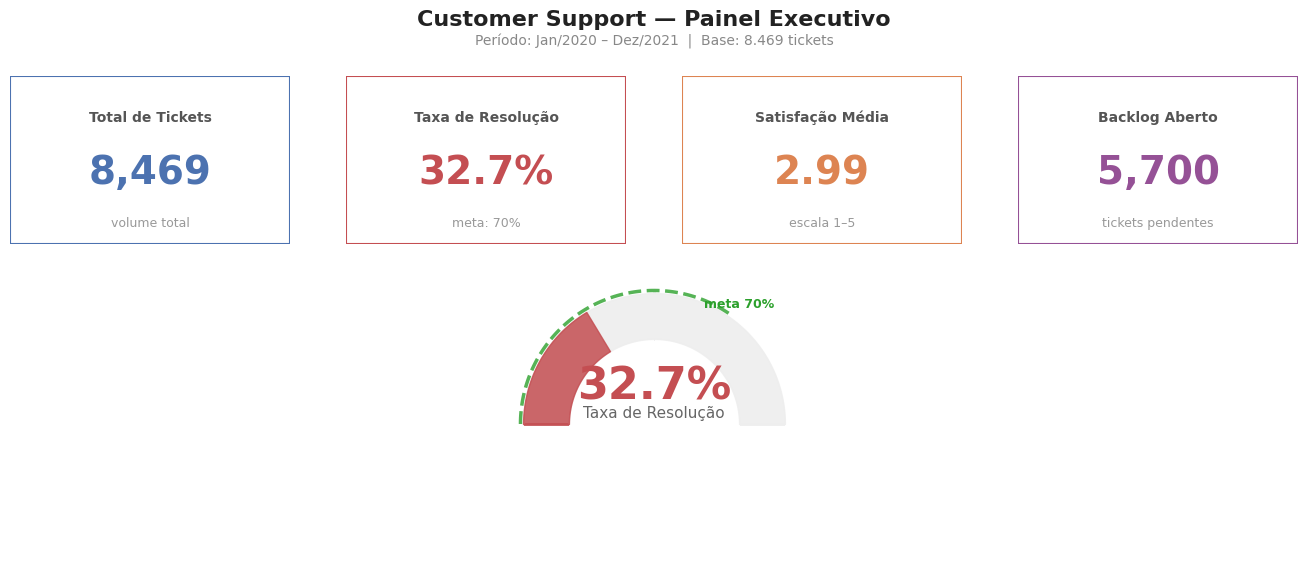

✅ Painel KPI salvo!


In [0]:
import builtins

# Calculando os KPIs
total_tickets  = f_tickets.count()
resolvidos     = f_tickets.filter(F.col("Status_ID") == 2).count()   # Status_ID 2 = Closed
taxa_resolucao = builtins.round(resolvidos / total_tickets * 100, 1)
backlog        = total_tickets - resolvidos

sat_media = (f_tickets
    .filter(F.col("Customer_Satisfaction_Rating").isNotNull())
    .agg(F.round(F.avg("Customer_Satisfaction_Rating"), 2))
    .collect()[0][0]
)

# ── Layout: 1 linha com 4 KPI cards + 1 gauge ──
fig = plt.figure(figsize=(14, 6))
fig.patch.set_facecolor("white")

# Título do dashboard
fig.text(0.5, 0.97, "Customer Support — Painel Executivo",
    ha="center", va="top", fontsize=16, fontweight="bold", color="#222")
fig.text(0.5, 0.93, "Período: Jan/2020 – Dez/2021  |  Base: 8.469 tickets",
    ha="center", va="top", fontsize=10, color="#888")

# ── KPI Cards (linha superior) ──
kpis = [
    ("Total de Tickets",    f"{total_tickets:,}",    "#4C72B0", "volume total"),
    ("Taxa de Resolução",   f"{taxa_resolucao}%",    "#c44e52", "meta: 70%"),
    ("Satisfação Média",    f"{sat_media}",           "#dd8452", "escala 1–5"),
    ("Backlog Aberto",      f"{backlog:,}",           "#955196", "tickets pendentes"),
]

for i, (titulo, valor, cor, sub) in enumerate(kpis):
    ax = fig.add_axes([0.04 + i * 0.24, 0.58, 0.20, 0.28])         # posição x, y, w, h
    ax.set_facecolor(cor + "18")                                     # fundo suave
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(0.5, 0.75, titulo, ha="center", va="center",
        fontsize=10, color="#555", fontweight="bold")
    ax.text(0.5, 0.42, valor, ha="center", va="center",
        fontsize=28, color=cor, fontweight="bold")
    ax.text(0.5, 0.12, sub, ha="center", va="center",
        fontsize=9, color="#999")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1,
        fill=False, edgecolor=cor, linewidth=1.5,
        transform=ax.transAxes))

# ── Gauge — Taxa de Resolução ──
ax_g = fig.add_axes([0.15, 0.04, 0.70, 0.48], polar=True)

theta_bg  = np.linspace(0, np.pi, 100)
theta_val = np.linspace(0, np.pi * (taxa_resolucao / 100), 100)
theta_meta = np.linspace(0, np.pi * 0.70, 100)                      # linha de meta 70%

ax_g.fill_between(theta_bg,  0.65, 1.0, color="#eeeeee", alpha=0.9)
ax_g.fill_between(theta_val, 0.65, 1.0, color="#c44e52", alpha=0.85)
ax_g.plot(theta_meta, [1.02] * 100,
    color="#2ca02c", linewidth=2.5,
    linestyle="--", alpha=0.8)                                       # linha de meta verde

ax_g.set_theta_zero_location("W")
ax_g.set_theta_direction(-1)
ax_g.set_ylim(0, 1.1)
ax_g.axis("off")

ax_g.text(np.pi/2, 0.28, f"{taxa_resolucao}%",
    ha="center", va="center",
    fontsize=32, fontweight="bold", color="#c44e52")
ax_g.text(np.pi/2, 0.08, "Taxa de Resolução",
    ha="center", va="center", fontsize=11, color="#666")
ax_g.text(np.pi * 0.70, 1.10, "meta 70%",
    ha="center", fontsize=9, color="#2ca02c", fontweight="bold")

plt.savefig(f"{OUTPUT_DIR}01_kpi_executivo.png",
    dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Painel KPI salvo!")

### Célula 3 — Evolução mensal: abertos vs fechados

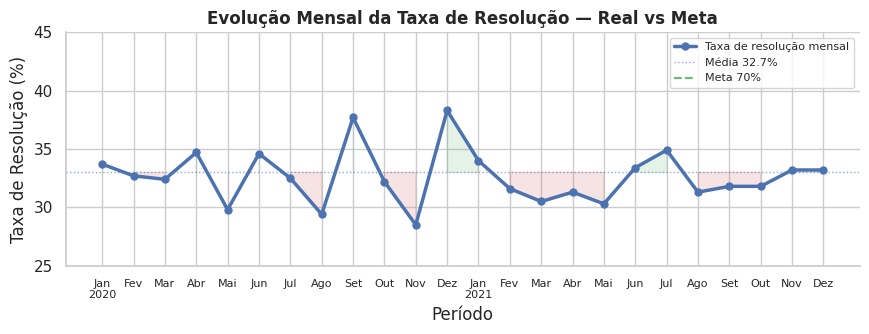

✅ Gráfico corrigido!


In [0]:
df_closed_mensal = (f_tickets
    .filter(F.col("Status_ID") == 2)                                 # apenas tickets fechados
    .groupBy("Purchase_Year", "Purchase_Month")
    .agg(F.count("*").alias("fechados"))
    .toPandas()
    .sort_values(["Purchase_Year", "Purchase_Month"])
)

df_total_mensal = (f_tickets
    .groupBy("Purchase_Year", "Purchase_Month")
    .agg(F.count("*").alias("total"))
    .toPandas()
    .sort_values(["Purchase_Year", "Purchase_Month"])
)

df_evo = df_total_mensal.merge(df_closed_mensal, on=["Purchase_Year", "Purchase_Month"])
df_evo["taxa"] = (df_evo["fechados"] / df_evo["total"] * 100).round(1)

meses = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
df_evo["label"] = df_evo.apply(
    lambda r: f"{meses[int(r['Purchase_Month'])-1]}\n{int(r['Purchase_Year'])}"
    if int(r["Purchase_Month"]) == 1
    else meses[int(r["Purchase_Month"])-1], axis=1)                  # cast para int

x = range(len(df_evo))

fig, ax = plt.subplots(figsize=(9, 3.5))

ax.fill_between(x, df_evo["taxa"], 33,
    where=df_evo["taxa"] >= 33,
    alpha=0.15, color="#55a868")                                     # área verde acima da média
ax.fill_between(x, df_evo["taxa"], 33,
    where=df_evo["taxa"] < 33,
    alpha=0.15, color="#c44e52")                                     # área vermelha abaixo

ax.plot(x, df_evo["taxa"], "o-",
    color="#4c72b0", linewidth=2.5,
    markersize=5, zorder=3, label="Taxa de resolução mensal")

ax.axhline(y=33, color="#4c72b0", linewidth=1,
    linestyle=":", alpha=0.6, label="Média 32.7%")                  # média real
ax.axhline(y=70, color="#2ca02c", linewidth=1.5,
    linestyle="--", alpha=0.7, label="Meta 70%")                    # meta

ax.set_ylim(25, 45)
ax.set_xticks(x)
ax.set_xticklabels(df_evo["label"], fontsize=8)
ax.set_title("Evolução Mensal da Taxa de Resolução — Real vs Meta")
ax.set_xlabel("Período")
ax.set_ylabel("Taxa de Resolução (%)")
ax.legend(fontsize=8, loc="upper right")
sns.despine()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}03_evolucao_resolucao.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico corrigido!")

### Célula 4 — Funil de Resolução por Prioridade

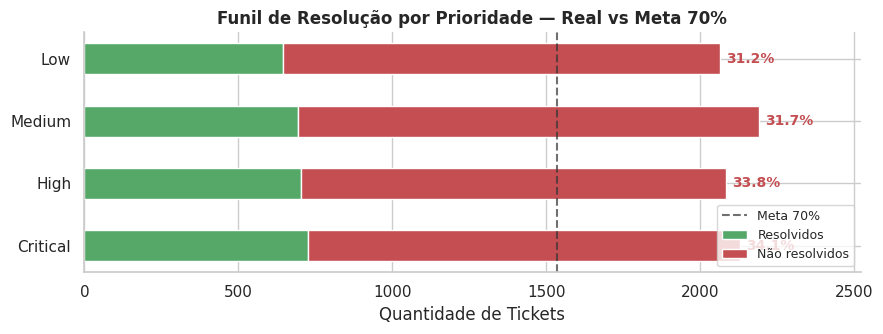

✅ Gráfico salvo!


In [0]:
import builtins

df_funil = (f_tickets
    .join(dim_priority, on="Priority_ID", how="left")
    .groupBy("Ticket_Priority")
    .agg(
        F.count("*").alias("total"),
        F.count(F.when(F.col("Status_ID") == 2, 1)).alias("resolvidos")
    )
    .toPandas()
)

df_funil["taxa"] = (df_funil["resolvidos"] / df_funil["total"] * 100).round(1)
df_funil["nao_resolvidos"] = df_funil["total"] - df_funil["resolvidos"]

ordem = ["Critical", "High", "Medium", "Low"]
df_funil["Ticket_Priority"] = pd.Categorical(df_funil["Ticket_Priority"], categories=ordem, ordered=True)
df_funil = df_funil.sort_values("Ticket_Priority")

fig, ax = plt.subplots(figsize=(9, 3.5))

bars_res = ax.barh(df_funil["Ticket_Priority"], df_funil["resolvidos"],
    color="#55a868", edgecolor="white", label="Resolvidos", height=0.5)
bars_nao = ax.barh(df_funil["Ticket_Priority"], df_funil["nao_resolvidos"],
    left=df_funil["resolvidos"],
    color="#c44e52", edgecolor="white", label="Não resolvidos", height=0.5)

# Meta de 70%
meta_x = df_funil["total"].max() * 0.70
ax.axvline(x=meta_x, color="#333", linewidth=1.5,
    linestyle="--", alpha=0.7, label="Meta 70%")

# Taxa dentro das barras
for _, row in df_funil.iterrows():
    ax.text(row["total"] + 20, ordem.index(row["Ticket_Priority"]),
        f'{row["taxa"]}%',
        va="center", fontsize=10, fontweight="bold",
        color="#c44e52" if row["taxa"] < 70 else "#55a868")          # vermelho se abaixo da meta

ax.set_title("Funil de Resolução por Prioridade — Real vs Meta 70%")
ax.set_xlabel("Quantidade de Tickets")
ax.set_xlim(0, df_funil["total"].max() * 1.15)
ax.legend(fontsize=9, loc="lower right")
sns.despine()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}02_funil_resolucao.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")

### Célula 5 — Tendência de Satisfação Mês a Mês

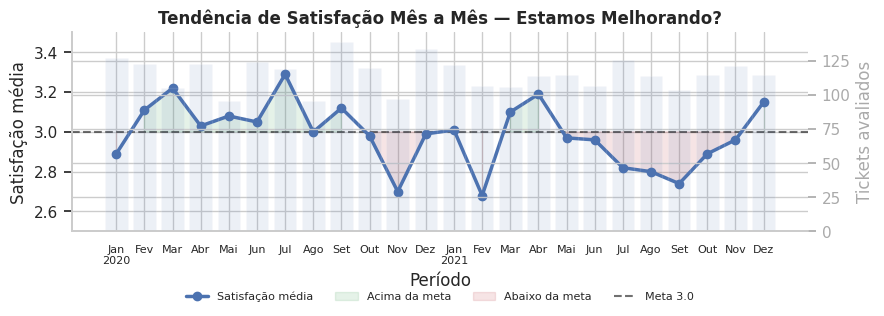

✅ Gráfico salvo!


In [0]:
df_tend = (f_tickets
    .filter(F.col("Customer_Satisfaction_Rating").isNotNull())
    .groupBy("Purchase_Year", "Purchase_Month")
    .agg(F.round(F.avg("Customer_Satisfaction_Rating"), 2).alias("satisfacao_media"),
         F.count("*").alias("total_avaliados"))
    .toPandas()
    .sort_values(["Purchase_Year", "Purchase_Month"])
)

meses = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
df_tend["periodo"] = df_tend["Purchase_Month"].apply(lambda m: meses[m-1])  # só nome do mês
df_tend["label"]   = df_tend.apply(                                          # label com ano só em Jan
    lambda r: f"{meses[r['Purchase_Month']-1]}\n{r['Purchase_Year']}"
    if r["Purchase_Month"] == 1 else meses[r["Purchase_Month"]-1], axis=1)

fig, ax1 = plt.subplots(figsize=(9, 3.5))

x = range(len(df_tend))                                              # índice numérico no eixo X

ax1.plot(x, df_tend["satisfacao_media"],
    "o-", color="#4c72b0", linewidth=2.5, markersize=6,
    label="Satisfação média", zorder=3)

ax1.fill_between(x, df_tend["satisfacao_media"], 3.0,
    where=df_tend["satisfacao_media"] >= 3.0,
    alpha=0.15, color="#55a868", label="Acima da meta")
ax1.fill_between(x, df_tend["satisfacao_media"], 3.0,
    where=df_tend["satisfacao_media"] < 3.0,
    alpha=0.15, color="#c44e52", label="Abaixo da meta")

ax1.axhline(y=3.0, color="#333", linewidth=1.5,
    linestyle="--", alpha=0.7, label="Meta 3.0")

ax1.set_ylim(2.5, 3.5)
ax1.set_ylabel("Satisfação média")
ax1.set_xticks(x)
ax1.set_xticklabels(df_tend["label"], fontsize=8)                   # label limpo com ano só em Jan

ax2 = ax1.twinx()
ax2.bar(x, df_tend["total_avaliados"],
    color="#4c72b0", alpha=0.10, label="Tickets avaliados")
ax2.set_ylabel("Tickets avaliados", color="#aaa")
ax2.tick_params(axis="y", colors="#aaa")

ax1.set_title("Tendência de Satisfação Mês a Mês — Estamos Melhorando?")
ax1.set_xlabel("Período")
ax1.legend(fontsize=8, loc="upper center",
    bbox_to_anchor=(0.5, -0.25),                                     # abaixo do gráfico
    ncol=4,                                                          # 4 itens por linha
    frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}05_tendencia_satisfacao.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")

### Célula 6 — Matriz: Produtos — Volume vs Satisfação

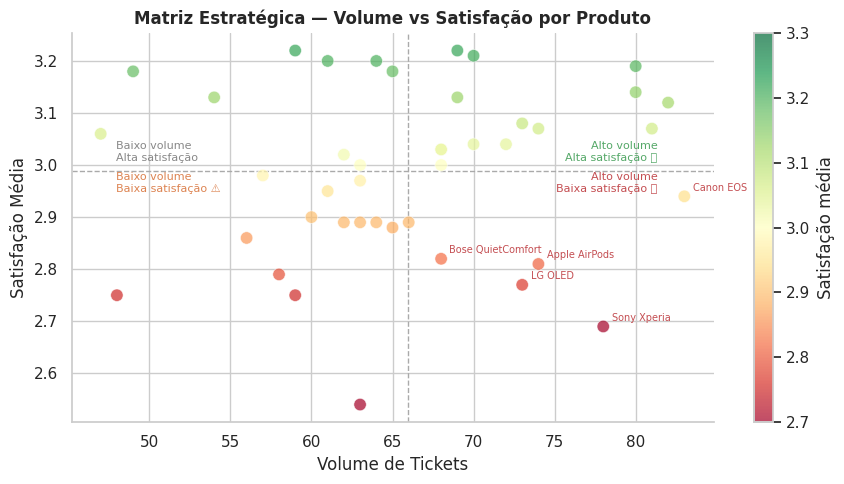

✅ Gráfico salvo!


In [0]:
df_matriz = (f_tickets
    .join(dim_product, on="Product_ID", how="left")
    .filter(F.col("Customer_Satisfaction_Rating").isNotNull())
    .groupBy("Product_Purchased")
    .agg(
        F.count("*").alias("volume"),
        F.round(F.avg("Customer_Satisfaction_Rating"), 2).alias("satisfacao_media")
    )
    .toPandas()
)

media_vol = df_matriz["volume"].mean()                               # linha divisória volume
media_sat = df_matriz["satisfacao_media"].mean()                     # linha divisória satisfação

fig, ax = plt.subplots(figsize=(9, 5))

scatter = ax.scatter(
    df_matriz["volume"],
    df_matriz["satisfacao_media"],
    s=80, alpha=0.7,
    c=df_matriz["satisfacao_media"],                                 # cor por satisfação
    cmap="RdYlGn",                                                   # vermelho → verde
    vmin=2.7, vmax=3.3,
    edgecolors="white", linewidth=0.5, zorder=3
)

# Linhas divisórias dos quadrantes
ax.axvline(x=media_vol, color="#aaa", linewidth=1, linestyle="--")
ax.axhline(y=media_sat, color="#aaa", linewidth=1, linestyle="--")

# Labels dos quadrantes
ax.text(df_matriz["volume"].max() * 0.98, media_sat + 0.02,
    "Alto volume\nAlta satisfação ✅", ha="right", fontsize=8, color="#55a868")
ax.text(df_matriz["volume"].max() * 0.98, media_sat - 0.04,
    "Alto volume\nBaixa satisfação 🔴", ha="right", fontsize=8, color="#c44e52")
ax.text(df_matriz["volume"].min() * 1.02, media_sat + 0.02,
    "Baixo volume\nAlta satisfação", ha="left", fontsize=8, color="#888")
ax.text(df_matriz["volume"].min() * 1.02, media_sat - 0.04,
    "Baixo volume\nBaixa satisfação ⚠️", ha="left", fontsize=8, color="#dd8452")

# Labels dos top produtos críticos
criticos = df_matriz[
    (df_matriz["volume"] > media_vol) &
    (df_matriz["satisfacao_media"] < media_sat)
].nlargest(5, "volume")

for _, row in criticos.iterrows():
    ax.annotate(row["Product_Purchased"],
        (row["volume"], row["satisfacao_media"]),
        textcoords="offset points", xytext=(6, 4),
        fontsize=7, color="#c44e52")

plt.colorbar(scatter, ax=ax, label="Satisfação média")
ax.set_title("Matriz Estratégica — Volume vs Satisfação por Produto")
ax.set_xlabel("Volume de Tickets")
ax.set_ylabel("Satisfação Média")
sns.despine()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}06_matriz_produto.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo!")

### Célula 7 — Ranking: Top 5 Assuntos Críticos por Insatisfação

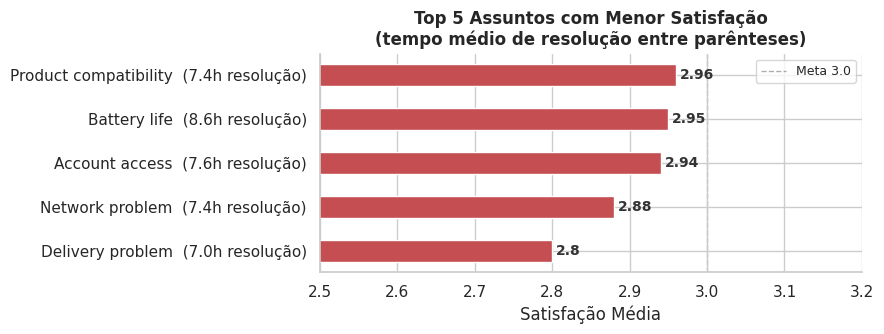

✅ Gráfico corrigido!


In [0]:
df_rank = (f_tickets
    .join(dim_subject, on="Subject_ID", how="left")
    .filter(F.col("Customer_Satisfaction_Rating").isNotNull())
    .filter(F.col("Resolution_Time_Hours").isNotNull())              # apenas com tempo registrado
    .groupBy("Ticket_Subject")
    .agg(
        F.count("*").alias("volume"),
        F.round(F.avg("Customer_Satisfaction_Rating"), 2).alias("satisfacao_media"),
        F.round(F.avg("Resolution_Time_Hours"), 1).alias("tempo_medio_horas")
    )
    .toPandas()
)

df_top5 = df_rank.nsmallest(5, "satisfacao_media").reset_index(drop=True)

df_top5["label"] = df_top5.apply(
    lambda r: f'{r["Ticket_Subject"]}  ({r["tempo_medio_horas"]}h resolução)', axis=1
)

fig, ax = plt.subplots(figsize=(9, 3.5))

cores = ["#c44e52" if v < 3.0 else "#dd8452"
    for v in df_top5["satisfacao_media"]]

ax.barh(df_top5["label"], df_top5["satisfacao_media"],
    color=cores, edgecolor="white", height=0.5)

ax.axvline(x=3.0, color="#333", linewidth=1,
    linestyle="--", alpha=0.4, label="Meta 3.0", zorder=0)

for i, (_, row) in enumerate(df_top5.iterrows()):
    ax.text(row["satisfacao_media"] + 0.005, i,
        f'{row["satisfacao_media"]}',
        va="center", fontsize=10,
        fontweight="bold", color="#333")

ax.set_xlim(2.5, 3.2)
ax.set_title("Top 5 Assuntos com Menor Satisfação\n(tempo médio de resolução entre parênteses)")
ax.set_xlabel("Satisfação Média")
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}07_ranking_assuntos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico corrigido!")

### Célula 8 — Volume por Tipo + Status

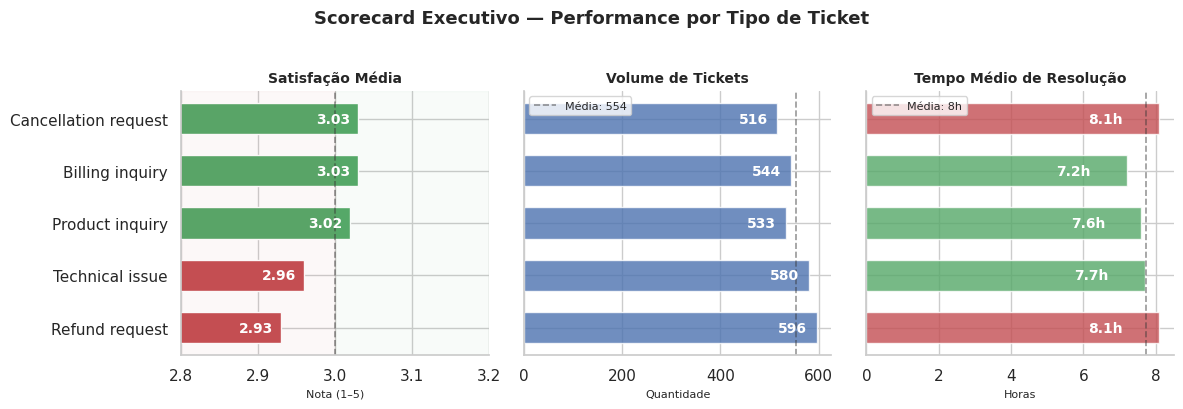

✅ Scorecard Executivo salvo!


In [0]:
df_score = (f_tickets
    .join(dim_type, on="Type_ID", how="left")
    .filter(F.col("Customer_Satisfaction_Rating").isNotNull())
    .groupBy("Ticket_Type")
    .agg(
        F.count("*").alias("volume"),
        F.round(F.avg("Customer_Satisfaction_Rating"), 2).alias("satisfacao"),
        F.round(F.count(F.when(F.col("Status_ID") == 2, 1)) /
                F.count("*") * 100, 1).alias("taxa_resolucao"),
        F.round(F.avg("Resolution_Time_Hours"), 1).alias("tempo_medio")
    )
    .toPandas()
    .sort_values("satisfacao", ascending=True)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4),
    gridspec_kw={"width_ratios": [2, 2, 2]})
fig.suptitle("Scorecard Executivo — Performance por Tipo de Ticket",
    fontsize=13, fontweight="bold", y=1.02)

# ── Painel 1: Satisfação média ──
ax = axes[0]
cores = ["#c44e52" if v < 3.0 else "#55a868" for v in df_score["satisfacao"]]
bars = ax.barh(df_score["Ticket_Type"], df_score["satisfacao"],
    color=cores, edgecolor="white", height=0.6)
ax.axvline(x=3.0, color="#333", linewidth=1.2, linestyle="--", alpha=0.5)
for bar, val in zip(bars, df_score["satisfacao"]):
    ax.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
        f"{val}", va="center", ha="right",
        fontsize=10, fontweight="bold", color="white")
ax.set_xlim(2.8, 3.2)
ax.set_title("Satisfação Média", fontsize=10, fontweight="bold")
ax.set_xlabel("Nota (1–5)", fontsize=8)
ax.axvspan(2.8, 3.0, alpha=0.04, color="#c44e52")                   # zona vermelha
ax.axvspan(3.0, 3.2, alpha=0.04, color="#55a868")                   # zona verde
sns.despine(ax=ax)

# ── Painel 2: Volume de tickets ──
ax = axes[1]
bars = ax.barh(df_score["Ticket_Type"], df_score["volume"],
    color="#4c72b0", edgecolor="white", height=0.6, alpha=0.8)
media_vol = df_score["volume"].mean()
ax.axvline(x=media_vol, color="#333", linewidth=1.2,
    linestyle="--", alpha=0.5, label=f"Média: {media_vol:.0f}")
for bar, val in zip(bars, df_score["volume"]):
    ax.text(bar.get_width() - 20, bar.get_y() + bar.get_height()/2,
        f"{val:,}", va="center", ha="right",
        fontsize=10, fontweight="bold", color="white")
ax.set_title("Volume de Tickets", fontsize=10, fontweight="bold")
ax.set_xlabel("Quantidade", fontsize=8)
ax.legend(fontsize=8)
ax.set_yticklabels([])                                               # remove labels duplicados
sns.despine(ax=ax)

# ── Painel 3: Tempo médio de resolução ──
ax = axes[2]
cores_t = ["#c44e52" if v > df_score["tempo_medio"].mean()
    else "#55a868" for v in df_score["tempo_medio"]]
bars = ax.barh(df_score["Ticket_Type"], df_score["tempo_medio"],
    color=cores_t, edgecolor="white", height=0.6, alpha=0.8)
media_tempo = df_score["tempo_medio"].mean()
ax.axvline(x=media_tempo, color="#333", linewidth=1.2,
    linestyle="--", alpha=0.5, label=f"Média: {media_tempo:.0f}h")
for bar, val in zip(bars, df_score["tempo_medio"]):
    ax.text(bar.get_width() - 1, bar.get_y() + bar.get_height()/2,
        f"{val}h", va="center", ha="right",
        fontsize=10, fontweight="bold", color="white")
ax.set_title("Tempo Médio de Resolução", fontsize=10, fontweight="bold")
ax.set_xlabel("Horas", fontsize=8)
ax.legend(fontsize=8)
ax.set_yticklabels([])                                               # remove labels duplicados
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}08_scorecard_executivo.png",
    dpi=150, bbox_inches="tight")
plt.show()
print("✅ Scorecard Executivo salvo!")

### Célula 9 — Painel de Alertas

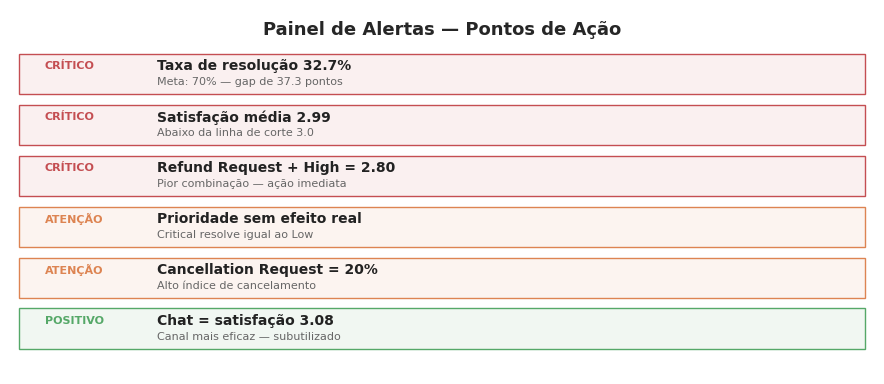

✅ Painel de Alertas salvo!


In [0]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.axis("off")

alertas = [
    ("🔴", "CRÍTICO",  "#c44e52", "Taxa de resolução 32.7%",        "Meta: 70% — gap de 37.3 pontos"),
    ("🔴", "CRÍTICO",  "#c44e52", "Satisfação média 2.99",           "Abaixo da linha de corte 3.0"),
    ("🔴", "CRÍTICO",  "#c44e52", "Refund Request + High = 2.80",    "Pior combinação — ação imediata"),
    ("🟡", "ATENÇÃO",  "#dd8452", "Prioridade sem efeito real",      "Critical resolve igual ao Low"),
    ("🟡", "ATENÇÃO",  "#dd8452", "Cancellation Request = 20%",      "Alto índice de cancelamento"),
    ("🟢", "POSITIVO", "#55a868", "Chat = satisfação 3.08",          "Canal mais eficaz — subutilizado"),
]

ax.text(0.5, 0.97, "Painel de Alertas — Pontos de Ação",
    ha="center", va="top", fontsize=13,
    fontweight="bold", transform=ax.transAxes)

for i, (emoji, nivel, cor, titulo, detalhe) in enumerate(alertas):
    y = 0.82 - i * 0.14

    # Fundo do card
    ax.add_patch(plt.Rectangle((0.01, y - 0.05), 0.98, 0.11,
        fill=True, facecolor=cor + "15",
        edgecolor=cor, linewidth=1,
        transform=ax.transAxes, clip_on=False))

    # Badge nível
    ax.text(0.04, y + 0.025, nivel,
        ha="left", va="center", fontsize=8,
        fontweight="bold", color=cor,
        transform=ax.transAxes)

    # Título
    ax.text(0.17, y + 0.025, titulo,
        ha="left", va="center", fontsize=10,
        fontweight="bold", color="#222",
        transform=ax.transAxes)

    # Detalhe
    ax.text(0.17, y - 0.018, detalhe,
        ha="left", va="center", fontsize=8,
        color="#666", transform=ax.transAxes)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}09_painel_alertas.png",
    dpi=150, bbox_inches="tight")
plt.show()
print("✅ Painel de Alertas salvo!")